# RetainIQ — Phase 6.1: Geospatial Dataset & Location Quality

I will build the geographic analysis dataset, verify that the customer grain is preserved, audit location completeness, validate coordinates, and understand where customers are concentrated.

## What I am checking

I am focusing on data quality first. A geographic retention analysis is only useful when the location fields are valid and the customer-level grain remains intact.

In [1]:
from getpass import getpass
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq",
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

def run_query(query, params=None):
    connection = None
    cursor = None
    try:
        connection = get_connection()
        cursor = connection.cursor(dictionary=True)
        cursor.execute(query, params or ())
        rows = cursor.fetchall()
        return pd.DataFrame(rows)
    except Error as exc:
        raise RuntimeError(f"MySQL query failed: {exc}") from exc
    finally:
        if cursor:
            cursor.close()
        if connection and connection.is_connected():
            connection.close()

def print_result(message):
    print(f"Result: {message}")


## 1. Load the customer-level geographic dataset

In [2]:
geo_query = """
SELECT
    f.customer_id,
    f.tenure_months,
    f.monthly_charge,
    f.total_revenue,
    f.satisfaction_score,
    f.cltv,
    f.churn_label,
    f.customer_status,
    l.country,
    l.state,
    l.city,
    l.zip_code,
    l.latitude,
    l.longitude,
    l.population,
    a.contract,
    a.payment_method,
    s.internet_type,
    s.premium_tech_support
FROM fact_customer_status f
JOIN dim_location l ON f.customer_id = l.customer_id
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id;
"""

geo_df = run_query(geo_query)
print_result(
    f"I loaded {len(geo_df):,} customer records with {geo_df.shape[1]} fields for geographic analysis."
)
display(geo_df.head())

Result: I loaded 7,043 customer records with 19 fields for geographic analysis.


,customer_id,tenure_months,monthly_charge,total_revenue,satisfaction_score,cltv,churn_label,customer_status,country,state,city,zip_code,latitude,longitude,population,contract,payment_method,internet_type,premium_tech_support
0,0002-ORFBO,9,65.60,974.81,3,2205,No,Stayed,United States,California,Frazier Park,93225,34.827662,-118.999073,4498,One Year,Credit Card,Cable,Yes
1,0003-MKNFE,9,59.90,610.28,5,5414,No,Stayed,United States,California,Glendale,91206,34.162515,-118.203869,31297,Month-to-Month,Credit Card,Cable,No
2,0004-TLHLJ,4,73.90,415.45,1,4479,Yes,Churned,United States,California,Costa Mesa,92627,33.645672,-117.922613,62069,Month-to-Month,Bank Withdrawal,Fiber Optic,No
3,0011-IGKFF,13,98.00,1599.51,1,3714,Yes,Churned,United States,California,Martinez,94553,38.014457,-122.115432,46677,Month-to-Month,Bank Withdrawal,Fiber Optic,No
4,0013-EXCHZ,3,83.90,289.54,1,3464,Yes,Churned,United States,California,Camarillo,93010,34.227846,-119.079903,42853,Month-to-Month,Credit Card,Fiber Optic,Yes


### Result & conclusion

The dataset is now at the customer level with location, value, service, account, and churn fields. I can use this as the geographic base table for the rest of Phase 6.

## 2. Validate the customer grain

In [3]:
expected_customers = 7043
actual_customers = len(geo_df)
unique_customers = geo_df["customer_id"].nunique()
duplicate_rows = int(geo_df["customer_id"].duplicated().sum())

assert actual_customers == expected_customers, f"Expected {expected_customers:,} rows, found {actual_customers:,}."
assert unique_customers == expected_customers, f"Expected {expected_customers:,} unique customers, found {unique_customers:,}."
assert duplicate_rows == 0, f"Found {duplicate_rows:,} duplicate customer rows."

print_result(
    f"I confirmed {actual_customers:,} rows, {unique_customers:,} unique customer IDs, and {duplicate_rows:,} duplicate customer rows."
)

Result: I confirmed 7,043 rows, 7,043 unique customer IDs, and 0 duplicate customer rows.


### Result & conclusion

The customer grain is preserved. Each customer appears exactly once, so market-level aggregation will not double-count customers.

## 3. Standardize numeric and geographic fields

In [4]:
numeric_columns = [
    "latitude", "longitude", "zip_code", "population",
    "tenure_months", "monthly_charge", "total_revenue",
    "satisfaction_score", "cltv"
]

for column in numeric_columns:
    geo_df[column] = pd.to_numeric(geo_df[column], errors="coerce")

converted = geo_df[numeric_columns].dtypes.astype(str).to_frame("dtype")
display(converted)
print_result("I converted the geographic and financial fields to numeric types so comparisons, ratios, and visualizations behave consistently.")

,dtype
latitude,float64
longitude,float64
zip_code,int64
population,int64
tenure_months,int64
monthly_charge,float64
total_revenue,float64
satisfaction_score,int64
cltv,int64


Result: I converted the geographic and financial fields to numeric types so comparisons, ratios, and visualizations behave consistently.


### Result & conclusion

The numeric fields are ready for analysis. Converting MySQL DECIMAL values explicitly also prevents object-dtype issues later.

## 4. Audit location completeness

In [5]:
location_columns = [
    "country", "state", "city", "zip_code",
    "latitude", "longitude", "population"
]

location_quality = pd.DataFrame({
    "missing": geo_df[location_columns].isna().sum()
})
location_quality["missing_pct"] = (
    location_quality["missing"] / len(geo_df) * 100
).round(2)

display(location_quality.sort_values("missing_pct", ascending=False))
worst_field = location_quality["missing_pct"].idxmax()
worst_pct = location_quality.loc[worst_field, "missing_pct"]
print_result(f"The location field with the highest missingness is '{worst_field}' at {worst_pct:.2f}%.")

,missing,missing_pct
country,0,0.00
state,0,0.00
city,0,0.00
zip_code,0,0.00
latitude,0,0.00
longitude,0,0.00
population,0,0.00


Result: The location field with the highest missingness is 'country' at 0.00%.


### Result & conclusion

I use this audit to separate complete geographic fields from partially populated ones. High missingness in a field reduces how confidently I can use that field for market-level comparison.

## 5. Validate latitude and longitude

In [6]:
valid_coords_mask = (
    geo_df["latitude"].between(-90, 90, inclusive="both")
    & geo_df["longitude"].between(-180, 180, inclusive="both")
)

valid_coords = geo_df[valid_coords_mask].copy()
coordinate_coverage_pct = len(valid_coords) / len(geo_df) * 100
invalid_coordinate_rows = int((~valid_coords_mask).sum())

print_result(
    f"I found {len(valid_coords):,} rows with valid coordinate ranges ({coordinate_coverage_pct:.2f}% coverage) and {invalid_coordinate_rows:,} rows outside valid ranges."
)

Result: I found 7,043 rows with valid coordinate ranges (100.00% coverage) and 0 rows outside valid ranges.


### Result & conclusion

Only valid coordinate ranges are used for spatial plots and geographic grid analysis. Rows without usable coordinates remain available for state/city analysis.

## 6. Check geographic coverage

In [7]:
coverage = pd.Series({
    "countries": geo_df["country"].nunique(dropna=True),
    "states": geo_df["state"].nunique(dropna=True),
    "cities": geo_df["city"].nunique(dropna=True),
    "zip_codes": geo_df["zip_code"].nunique(dropna=True)
})

display(coverage.to_frame("unique_values"))
print_result(
    f"The dataset covers {int(coverage['states']):,} states, {int(coverage['cities']):,} cities, and {int(coverage['zip_codes']):,} ZIP codes."
)

,unique_values
countries,1
states,1
cities,1106
zip_codes,1626


Result: The dataset covers 1 states, 1,106 cities, and 1,626 ZIP codes.


### Result & conclusion

The coverage counts show the geographic resolution available to me. State and city are the primary market dimensions; ZIP codes and coordinates are used for deeper spatial detail where the data supports it.

## 7. Customer concentration by state

In [11]:
state_distribution = (
    geo_df.groupby("state", dropna=False)
    .size()
    .rename("customers")
    .sort_values(ascending=False)
    .to_frame()
)
state_distribution["share_pct"] = (
    state_distribution["customers"] / len(geo_df) * 100
).round(2)

display(state_distribution.head(15))
top_state = state_distribution.index[0]
top_state_share = state_distribution.iloc[0]["share_pct"]
print_result(f"The most concentrated state in the customer base is '{top_state}', representing {top_state_share:.2f}% of customers.")

,customers,share_pct
state,,
California,7043,100.00


Result: The most concentrated state in the customer base is 'California', representing 100.00% of customers.


### Result & conclusion

Customer concentration matters when I compare market churn. A market with many more customers can produce more absolute churn and revenue exposure even when its churn rate is not the highest.

## 8. Customer concentration by city

In [12]:
city_distribution = (
    geo_df.groupby("city", dropna=False)
    .size()
    .rename("customers")
    .sort_values(ascending=False)
    .to_frame()
)
city_distribution["share_pct"] = (
    city_distribution["customers"] / len(geo_df) * 100
).round(2)

display(city_distribution.head(20))
top_city = city_distribution.index[0]
top_city_share = city_distribution.iloc[0]["share_pct"]
print_result(f"The largest city market contains {int(city_distribution.iloc[0]['customers']):,} customers, representing {top_city_share:.2f}% of the full customer base.")

,customers,share_pct
city,,
Los Angeles,293,4.16
San Diego,285,4.05
San Jose,112,1.59
Sacramento,108,1.53
San Francisco,104,1.48
Fresno,61,0.87
Long Beach,60,0.85
Oakland,52,0.74
Escondido,51,0.72


Result: The largest city market contains 293 customers, representing 4.16% of the full customer base.


### Result & conclusion

The city distribution helps me identify markets where retention activity could affect a large customer population. I will still apply a minimum market-size rule before comparing churn rates.

## 9. Plot the geographic customer distribution

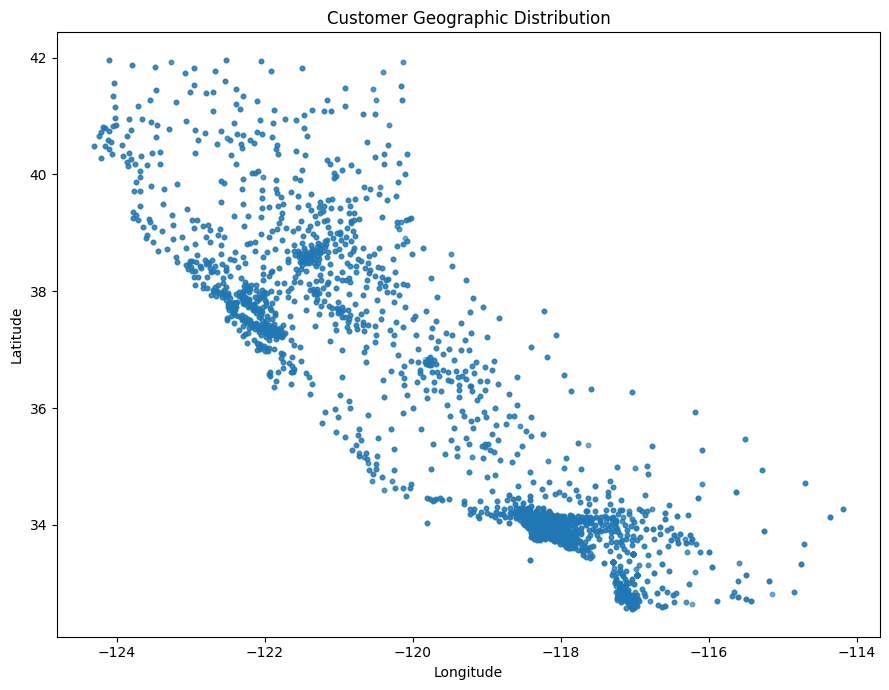

Result: The scatter plot shows where valid-coordinate customers are concentrated and where the customer footprint is sparse.


In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    valid_coords["longitude"],
    valid_coords["latitude"],
    s=10,
    alpha=0.35
)
ax.set_title("Customer Geographic Distribution")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print_result("The scatter plot shows where valid-coordinate customers are concentrated and where the customer footprint is sparse." )

### Result & conclusion

The plot is descriptive rather than causal. It helps me see the geographic footprint and concentration pattern, but geography alone does not explain why customers churn.

## 10. Compare local population with customer concentration

In [14]:
market_population = (
    geo_df.groupby(["state", "city", "zip_code"], dropna=False)
    .agg(
        customers=("customer_id", "count"),
        population=("population", "max")
    )
    .reset_index()
)

market_population["customers_per_population"] = (
    market_population["customers"] /
    market_population["population"].replace(0, np.nan)
)

display(market_population.sort_values("customers", ascending=False).head(20))
valid_penetration = market_population["customers_per_population"].dropna()
print_result(
    f"I have {len(valid_penetration):,} market-location rows with a usable population value for customer-to-population comparison."
)

,state,city,zip_code,customers,population,customers_per_population
391,California,Fallbrook,92028,43,42239,0.00
379,California,Escondido,92027,38,48690,0.00
1219,California,San Diego,92122,36,34902,0.00
1215,California,San Diego,92117,34,51213,0.00
1222,California,San Diego,92126,32,74232,0.00
1471,California,Temecula,92592,30,46171,0.00
1208,California,San Diego,92109,27,46086,0.00
1226,California,San Diego,92130,22,28201,0.00
1218,California,San Diego,92121,20,4258,0.00
1225,California,San Diego,92129,16,47224,0.00


Result: I have 1,626 market-location rows with a usable population value for customer-to-population comparison.


### Result & conclusion

Customer concentration and population are not the same thing. This comparison gives me context for whether a market is simply large or has an unusually high customer presence relative to the available population field.

## 11. Interpretation rule for geography

I will treat geography as a descriptive business dimension. A market with higher churn is a place where the observed retention pattern is different; it is not evidence that geography itself causes churn.

# Phase 6.1 conclusion

I now have a validated customer-level geographic dataset, a location-quality audit, coordinate coverage metrics, and a clear view of customer concentration. The dataset is ready for state- and city-level retention analysis in Phase 6.2.